# Code for plots in Fig. S5

In [3]:
# import libraries
import numpy as np
import matplotlib as mpl
mpl.use("Qt5Agg")
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os,sys,inspect
%matplotlib inline

# import modules
currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)
from decoding_population import Cross_var,Window_subject_decoder
from simulation import Simulation_neuralspace, Simulation_forstats
from utilities import format_axs,plot_state_points,plot_state_cloud,\
plot_hyperplane,compute_pvalues_trace_corrected,plot_pvalues_trace

## Fig  S5A
### Cross-condition decoding in trial time for variables (category, choice, outcome) with all splits

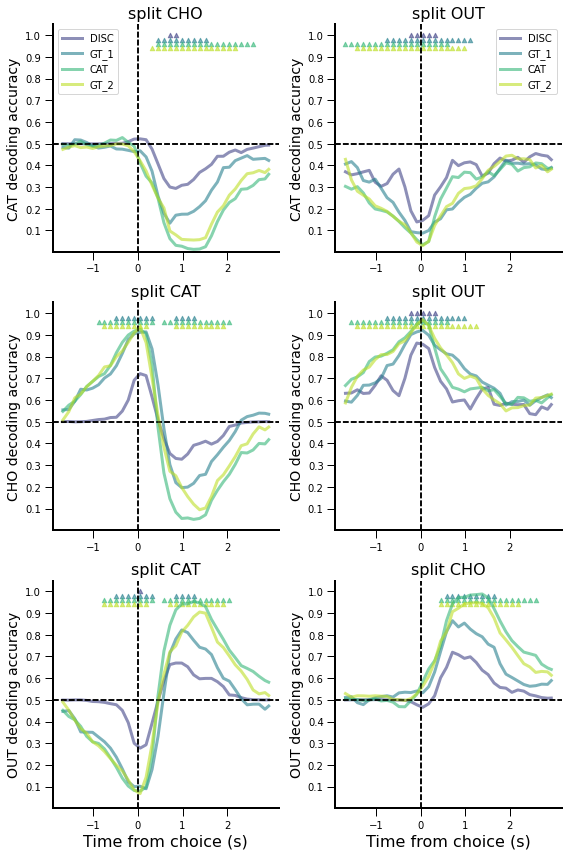

In [4]:
%matplotlib inline
def pseudopop_geometry():
    '''
    panel with phases x variables for each alignment
    pseudopopulation 
    '''
    variables = ['category', 'choice', 'outcome']
    event_align = 'choice'
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    label_dict = {
        'discrimination':'DISC',
        'gentest_1':'GT_1',
        'categorization_4':'CAT',
        'gentest_2':'GT_2'}
    
    colors = plt.cm.viridis(np.linspace(0.2,0.9,len(phases)))
    
    fig,axs = plt.subplots(len(variables),len(variables)-1)
    fig.set_figwidth(4*(len(variables)-1))
    fig.set_figheight(4*len(variables))

    for i,v in enumerate(variables):
        cross_variables = variables.copy()
        cross_variables.pop(i)
        for phase in phases:
            color_idx = phases.index(phase)
            
            entry = Cross_var()\
                & 'experimental_timepoint="%s"'%phase & 'variable="%s"'%v \
                    & 'event_align="%s"'%event_align
                    
            cross_acc_all = entry.fetch('cross_var_acc')[0]
            timepoints = entry.fetch('timepoints')[0]
            null_all = entry.fetch('cross_var_null')[0]
            assert cross_variables == entry.fetch('cross_variables')[0]
            
            for j,cross_v in enumerate(cross_variables):
                acc = np.mean(cross_acc_all[:,j],0)
                null = null_all[:,j]
                
                _,pvalues_acc = compute_pvalues_trace_corrected(acc,null,stat_type='two-sided') # two-sided
                
                
                axs[i,j].plot(timepoints,acc,color=colors[color_idx],linewidth=3,alpha=0.6,
                              label = label_dict[phase])
                axs[i,j] = plot_pvalues_trace(axs[i,j],pvalues_acc,timepoints,
                                        1-color_idx*0.02,colors[color_idx],alpha=0.6)
                
                axs[i,j].set_ylabel('%s decoding accuracy'%v[:3].upper(),fontsize=14)
                axs[i,j].axvline(x=0,linestyle='--',color='black',alpha=0.7)
                axs[i,j].axhline(y=0.5,linestyle='--',color='black',alpha=0.7)
                axs[i,j].set_ylim(0,1.05)
                axs[i,j].set_yticks(np.arange(0.1,1.05,0.1))
                axs[i,j].set_xticks(np.arange(int(timepoints[0]),int(timepoints[-1])+0.5,1))
                axs[i,j].spines["top"].set_visible(False)
                axs[i,j].spines["right"].set_visible(False)
                axs[i,j].spines["bottom"].set_linewidth(2)
                axs[i,j].spines["left"].set_linewidth(2)
                axs[i,j].tick_params(size= 8,width=1, length=10) # labelsize = labelsize
                axs[i,j].set_title('split %s'%cross_v[:3].upper(),fontsize=16)
                if i == 0:
                    
                    axs[i,j].legend()
                elif i == len(variables)-1:
                    for ax in axs[i]:
                        ax.set_xlabel('Time from %s (s)'%event_align,fontsize=16)

        
    plt.tight_layout()
    plt.show()
    
pseudopop_geometry()

## Fig S6B
### Example of simulation of neural state space with dimensionality d=2 (governed by choice and outcome)

In [5]:
def plot_geometries(valid_keys,nr_plot=5):
    colors_dict = {'BL':'tab:cyan',
                   'AR':'tab:olive',
                   'AL':'tab:gray',
                   'BR':'tab:orange'}

    state_labels = list(colors_dict.keys())
    state_vars = ['category','choice','outcome']
    n_states = 4
    
    # if more than 10 select randomly
    if len(valid_keys) > nr_plot:
        random = np.random.randint(0,len(valid_keys),nr_plot)
        valid_keys = np.array(valid_keys)[random]
    for key in valid_keys:
        simulation_entry = Simulation_neuralspace() & key
    
        state_clouds = simulation_entry.fetch('state_clouds')[0]
        state_points = np.mean(state_clouds,1)
        decoding_vectors = simulation_entry.fetch('decoding_vectors')[0]
        
        for j,v in enumerate(state_vars):                                                                     
            fig_single = plt.figure()
            ax1  = fig_single.add_subplot(111, projection='3d')
            ax1 = plot_state_points(state_points,ax1)
            # n_states x n_trials x n_dims
            ax1 = plot_state_cloud(n_states,state_clouds,ax1,colors_dict,state_labels)
            decoder_vector = decoding_vectors[j][0]
            decoder_intercept = decoding_vectors[j][1]
            ax1 = plot_hyperplane(state_clouds,decoder_vector,decoder_intercept,ax1)
            v_label = v[:3]+ '_acc'
            acc = round(simulation_entry.fetch(v_label)[0],2)
            ax1.set_title('id: %i var: %s %s'%(key['geometry_id'],v[:3],str(acc)))

category decoding accuracy:  0.551667
choice decoding accuracy:  0.94175
outcome decoding accuracy:  0.867
choice (cross-condition) decoding accuracy:  [0.75182143 0.75414286]
outcome (cross-condition) decoding accuracy:  [0.64142857 0.68753571]


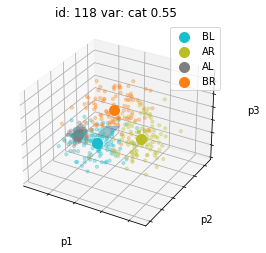

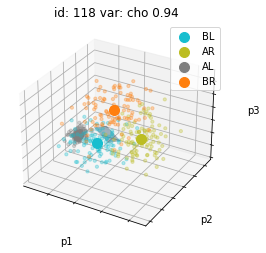

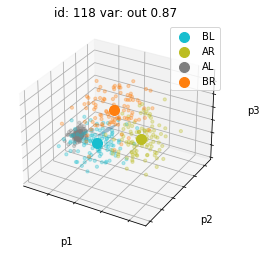

In [6]:
key = {'geometry_id':118}
entry = Simulation_neuralspace() & key
print('category decoding accuracy: ', entry.fetch('cat_acc')[0])
print('choice decoding accuracy: ', entry.fetch('cho_acc')[0])
print('outcome decoding accuracy: ', entry.fetch('out_acc')[0])
print('choice (cross-condition) decoding accuracy: ', entry.fetch('cho_cross_out')[0])
print('outcome (cross-condition) decoding accuracy: ', entry.fetch('out_cross_cho')[0])
plot_geometries([key])

## Fig S6C
### 2-d histogram on dimensionality of  simulations  constrained to values of cross-condition decoding accuracies

Legend dimensionality {1: 'Blues', 2: 'Greens', 3: 'Reds'}


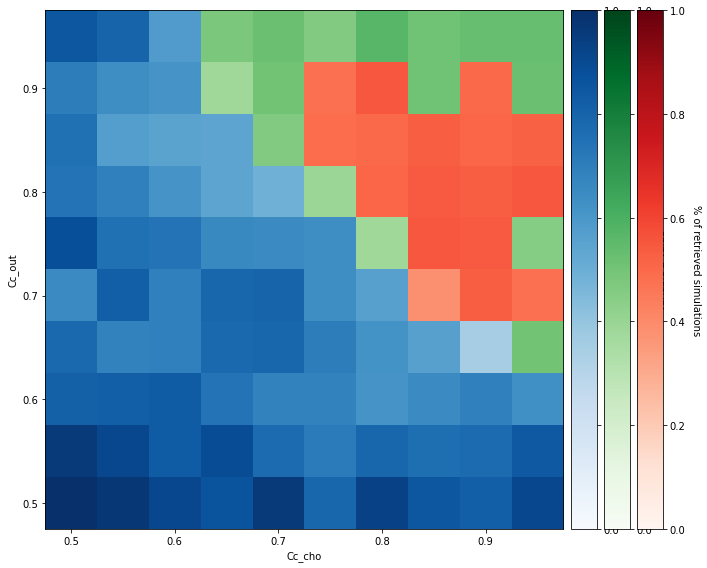

In [7]:
def plot_dim_vs_cc_2d():
    
    # constraints 
    step = 0.05
    vals_1 = np.arange(0.95,0.45,-step)
    vals_2 = np.arange(0.5,1,step)
    data = np.zeros((len(vals_1),len(vals_1),3))
    dim_values = np.zeros((len(vals_1),len(vals_1),3))
    dim_stats = np.zeros((len(vals_1),len(vals_1),3))
    
    # constrain simulations with decoding accuracy for category below 75%
    entries = Simulation_forstats() 
    entries = entries & 'cat_acc<="%s"'%(str(0.75))
        
    for i,val_1 in enumerate(vals_1):
        for j,val_2 in enumerate(vals_2):
            sim_entries = entries & 'cho_acc<="%s"'%(str(val_1 + step/2))
            sim_entries = sim_entries & 'cho_acc>="%s"'%(str(val_1 - step/2))
            
            sim_entries = sim_entries & 'out_acc<="%s"'%(str(val_2 + step/2))
            sim_entries = sim_entries & 'out_acc>="%s"'%(str(val_2 - step/2))
            
            # count according to dimensionality bins
            dims = sim_entries.fetch('dim')
            data[i,j] = [len(np.where(dims==i+1)[0]) for i in range(3)]
            d_arg = np.argsort(data[i,j])
            for k in range(len(d_arg)):
                dim_values[i,j,k] = d_arg[k] + 1
                dim_stats[i,j,k] = round(data[i,j,d_arg[k]] / sum(data[i,j]),2)
                
    # plot 2d histogram 
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Define colormaps for each variable
    cmaps = {1: 'Blues', 2: 'Greens', 3: 'Reds'}
    print('Legend dimensionality',cmaps)
    norms = {1: Normalize(vmin=0, vmax=1), 2: Normalize(vmin=0, vmax=1), 3: Normalize(vmin=0, vmax=1)}

    # Create masked arrays for each variable
    k=2 # most common dimensionality for each bin
    images = []
    for var in [1, 2, 3]:
        mask = dim_values[:,:,k] == var
        data = np.ma.masked_where(~mask, dim_stats[:,:,k])
        im = ax.imshow(data, cmap=cmaps[var], norm=norms[var], interpolation='nearest')
        images.append(im)

    # Add colorbars for each variable
    divider = make_axes_locatable(ax)
    for var in [1, 2, 3]:
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig.colorbar(images[var-1], cax=cax, label=f'Variable {var} Value',aspect=15,pad=0.2)
    
    cbar.set_label(f'% of retrieved simulations', rotation=270, labelpad=15)

    ax.set_xticks([0, 2, 4, 6, 8])
    ax.set_yticks([1, 3, 5, 7, 9])
    xtick_labels = [round(val,2) for val in np.arange(0.5,1,0.1)]
    ytick_labels = [round(val,2) for val in np.arange(0.9,0.4,-0.1)]
    ax.set_xticklabels(xtick_labels)
    ax.set_yticklabels(ytick_labels)
    
    ax.set_xlabel('Cc_cho')
    ax.set_ylabel('Cc_out')
    plt.tight_layout()
                
plot_dim_vs_cc_2d()

bin #1
bin #2
bin #3
bin #4


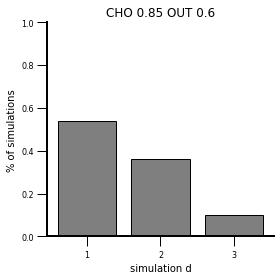

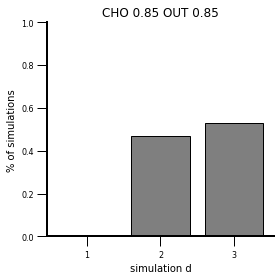

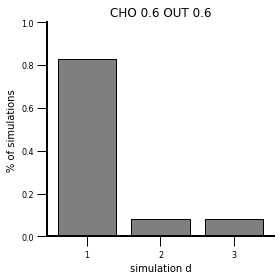

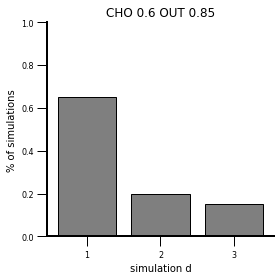

In [8]:
def stats_dim_cc_2d():
    
# constraints 
    step = 0.05
    vals_1 = np.array([0.85,0.6])
    vals_2 = np.array([0.6,0.85])
    
    # constrain to simulations with decoding accuracy for category below 75%
    entries = Simulation_forstats() 
    entries = entries & 'cat_acc<="%s"'%(str(0.75))
    bin_nr=1
    for i,val_1 in enumerate(vals_1):
        for j,val_2 in enumerate(vals_2):
            sim_entries = entries & 'cho_acc<="%s"'%(str(val_1 + step/2))
            sim_entries = sim_entries & 'cho_acc>="%s"'%(str(val_1 - step/2))
            
            sim_entries = sim_entries & 'out_acc<="%s"'%(str(val_2 + step/2))
            sim_entries = sim_entries & 'out_acc>="%s"'%(str(val_2 - step/2))
            
            # count according to dimensionality bins
            dims = sim_entries.fetch('dim')
            nr_entries = len(sim_entries)
            print('bin #%i'%bin_nr)
            bin_nr+=1
            fig, axs = plt.subplots()
            fig.set_figheight(4)
            fig.set_figwidth(4)  

            categories = []
            values = []
            for d in range(3):
                categories.append(d+1)
                values.append(round(len(np.where(dims==d+1)[0])/nr_entries,2))
                
            axs.bar(categories, values,edgecolor='black', color='tab:gray')
            axs.set_xticks(categories)
        
            #
            axs.set_ylabel('% of simulations')
            axs.set_xlabel('simulation d')
            axs.set_title('CHO %s OUT %s'%(str(val_1),str(val_2)))
            axs = format_axs(axs)   
            axs.set_ylim(0,1)
            plt.tight_layout()
            
stats_dim_cc_2d()

## Fig S6D
### Population activity (color coded by trial type) in the post-choice window projected onto 2d plane given by decoding dimension for Choice and Outcome for each subject

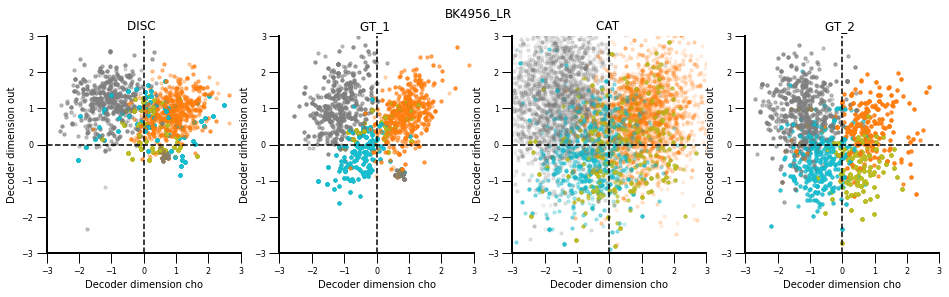

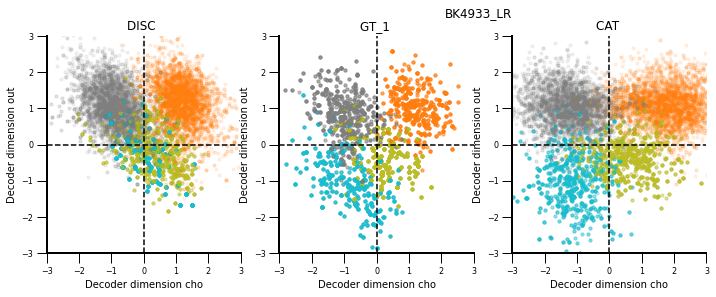

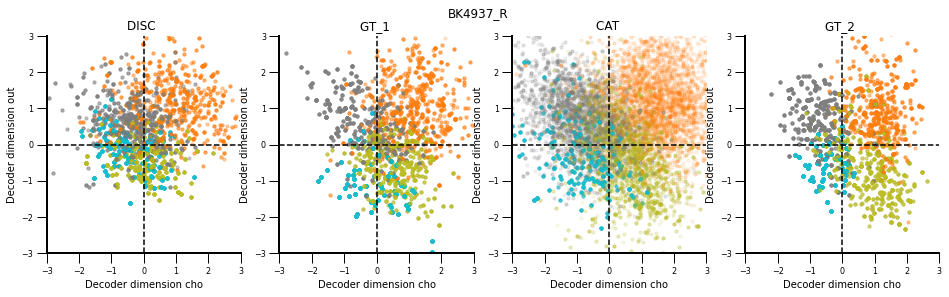

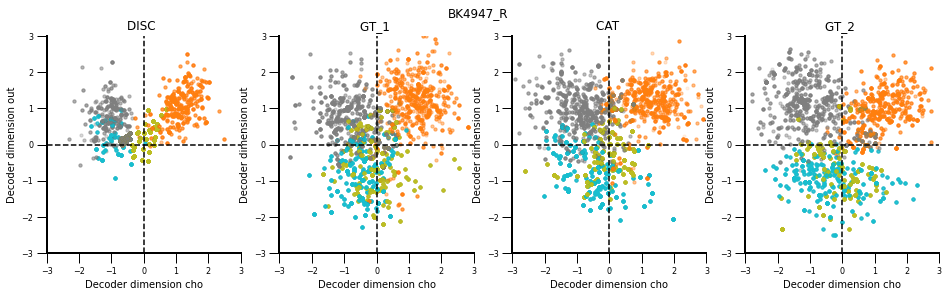

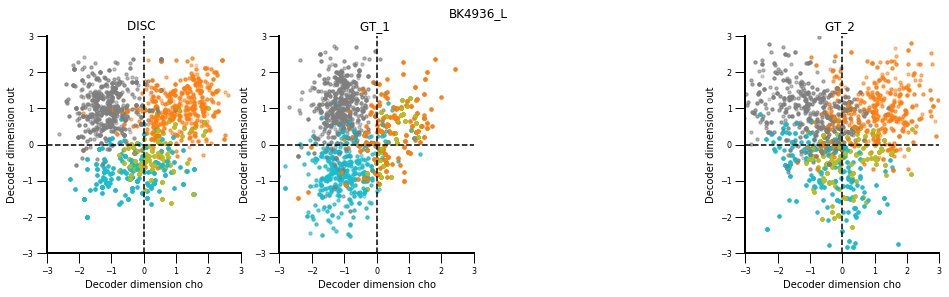

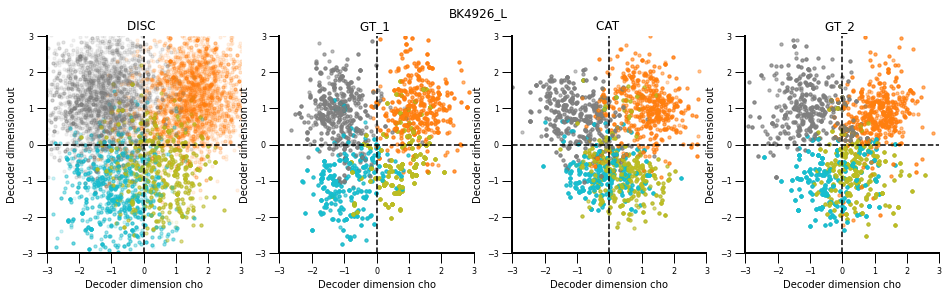

In [9]:
def decoding_space_2d_subject(window_length=1):
    colors_dict = {'BL':'tab:cyan',
                   'AR':'tab:olive',
                   'AL':'tab:gray',
                   'BR':'tab:orange'}
    
    state_combinations = {(1, 0, 0):'BL',
                   (0, 1, 0):'AR',
                   (0, 0, 1):'AL',
                   (1, 1, 1):'BR'}
    
    stages = ['discrimination','gentest_1','categorization_4','gentest_2']
    stage_labels = ['DISC','GT_1','CAT','GT_2']
    window = 'post_choice'
    
    animal_ids = ['BK4956_LR', 'BK4933_LR', 'BK4937_R', 
                  'BK4947_R', 'BK4936_L', 'BK4926_L']
    
    for animal_id in animal_ids:
        
        fig = plt.figure()
        fig.suptitle('%s'%animal_id)
        fig.set_figheight(4)
        fig.set_figwidth(4*len(stages))
        
        for i,stage in enumerate(stages):
            entry = Window_subject_decoder() & 'experimental_timepoint="%s"'%stage \
                    & 'window="%s"'%window \
                        & 'window_length="%s"'%window_length \
                            & 'animal_id="%s"'%(animal_id+ '-40p')
            if len(entry) != 0:
                accuracy = np.array(entry.fetch('accuracy')[0])
                # accuracy for choice and outcome
                # excluding related category term
                # ccgp shape  nr vars x nr cross vars
                ccgp = np.array(entry.fetch('ccgp')[0])[:,1]
                x_test =  np.array(entry.fetch('x_test')[0])
                # nr runs x nr vars x nr neurons 
                dec_vecs = np.array(entry.fetch('decoder_vec')[0])
                combinations = entry.fetch('combinations')[0]
                
                nr_states = len(combinations)
                nr_runs = x_test.shape[0]
                nr_neurons = x_test.shape[-1]
                nr_trials = x_test.shape[-2]
                assert nr_trials % nr_states == 0
                nr_trials_state = int(nr_trials / nr_states)
                axs  = fig.add_subplot(1,len(stages),i+1)
        
                for idx in range(nr_runs): 
                    # projection dimensions - decoding vectors of choice and outcome
                    proj_dims = dec_vecs[idx,1:]
                    assert proj_dims.shape[0] == 2 #  choice and outcome
                    
                    assert proj_dims.shape[-1] == nr_neurons #  choice and outcome
                        
                    # scatter plot with projected data
                    for s in range(nr_states):
                        combination = combinations[s]
                        state_label = state_combinations[combination]
                        # nr runs x nr conditions*nr trials x nr neurons 
                        trial_idx = s * nr_trials_state
                        
                        data_state = x_test[idx,trial_idx:trial_idx+nr_trials_state]
                        # project onto decoder plane
                        data_proj = data_state.dot(proj_dims.T)
                        
                        axs.scatter(data_proj[:, 0],data_proj[:, 1],
                                c=colors_dict[state_label],
                                s=10, alpha=0.1,label=state_label)
                        
                axs.axvline(x=0,linestyle='--',color='black')
                axs.axhline(y=0,linestyle='--',color='black')
                axs.set_xlabel('Decoder dimension cho')
                axs.set_ylabel('Decoder dimension out')
                axs.set_xlim(-3,3) 
                axs.set_ylim(-3,3)
                        
                # subtitle stage
                axs.set_title('%s '%stage_labels[i])
                # format axs
                axs = format_axs(axs)
                
decoding_space_2d_subject()